<a href="https://colab.research.google.com/github/dgb1106/PM2.5-Prediction/blob/main/PM2_5_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import dataset

In [ ]:
file_path = '/content/drive/MyDrive/PM2.5-prediction-dataset/data_onkk.csv'

In [ ]:
df = pd.read_csv(file_path)
df.head()

,time,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
0,2020-01-01,19,116.949130,21.049750,105.741870,5.922647,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
1,2020-01-01,79,105.103043,21.015250,105.800130,4.307231,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
2,2020-01-01,163,118.285100,21.024347,106.017288,4.988467,0.651509,145.395233,20.677492,23.029993,18.879999,0.1250,73.687500,102228.796875
3,2020-01-01,300,116.739130,21.023532,105.853941,4.865087,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
4,2020-01-02,19,76.856667,21.049750,105.741870,5.922647,2.744283,147.084442,22.176249,25.119989,20.299982,0.1875,78.012497,102025.328125


In [ ]:
df.dtypes

,0
time,object
ID,int64
pm25,float64
lat,float64
lon,float64
SQRT_SEA_DEM_LAT,float64
WSPD,float64
WDIR,float64
TMP,float64
TX,float64


In [ ]:
df.describe()

,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
count,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000,11508.000000
mean,125.563434,35.549743,21.101977,106.018574,5.325964,2.783826,128.810995,24.694296,28.780240,21.765171,3.501670,71.770136,100954.143533
std,70.516935,29.450255,0.085400,0.238192,0.620108,1.378970,78.842842,5.099146,6.039901,4.751163,7.465766,11.816262,709.711910
min,5.000000,3.023100,20.927000,105.367300,3.382894,0.020039,0.093567,9.192495,11.040003,7.230005,0.000000,25.900000,99105.140625
25%,60.000000,16.326228,21.027221,105.889544,4.865087,1.696836,87.590500,20.934993,24.409120,18.265497,0.000000,64.862503,100340.634766
50%,156.000000,27.171879,21.113745,106.017288,5.465172,2.720441,136.356522,24.915009,28.959986,22.269983,0.626563,74.097496,100946.343750
75%,163.000000,44.422146,21.152745,106.151880,5.693217,3.773106,150.831589,28.925005,33.412499,25.661511,3.312500,80.599998,101519.875000
max,300.000000,241.724021,21.338470,106.529100,6.696101,9.585102,359.884491,34.650002,41.749992,30.850000,106.687500,97.972504,102818.328125


In [ ]:
missing_values = df.isnull().sum()
print(missing_values)

time                0
ID                  0
pm25                0
lat                 0
lon                 0
SQRT_SEA_DEM_LAT    0
WSPD                0
WDIR                0
TMP                 0
TX                  0
TN                  0
TP                  0
RH                  0
PRES2M              0
dtype: int64


Count the number of stations

In [ ]:
num_of_stations = df['ID'].nunique()
print('Number of stations:', num_of_stations)
stations = df['ID'].unique()
print('Stations:', stations)

Number of stations: 26
Stations: [ 19  79 163 300  51  52  53  62  66  71 155 156 157 158 160 162 159 195
   5 169  60 172 173  54 175 161]


In [ ]:
df_ID_19 = df[df['ID'] == 19]
df_ID_19

,time,ID,pm25,lat,lon,SQRT_SEA_DEM_LAT,WSPD,WDIR,TMP,TX,TN,TP,RH,PRES2M
0,2020-01-01,19,116.949130,21.04975,105.74187,5.922647,1.136119,145.942749,20.811243,23.219995,18.939997,0.3750,74.750000,102197.203125
4,2020-01-02,19,76.856667,21.04975,105.74187,5.922647,2.744283,147.084442,22.176249,25.119989,20.299982,0.1875,78.012497,102025.328125
20,2020-01-03,19,48.973750,21.04975,105.74187,5.922647,3.848651,139.636887,22.586241,25.809992,20.279993,0.5625,77.125000,101829.679688
28,2020-01-04,19,47.220833,21.04975,105.74187,5.922647,3.850519,130.682007,22.094999,24.670008,20.700006,1.6250,79.937500,101635.898438
32,2020-01-05,19,50.377083,21.04975,105.74187,5.922647,4.113763,132.044159,21.714987,26.019983,19.609980,1.0625,82.325005,101532.335938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10268,2021-09-07,19,33.197917,21.04975,105.74187,5.922647,2.223937,338.294281,27.875006,31.350000,25.150019,13.5625,78.450005,100832.000000
10281,2021-09-08,19,23.564583,21.04975,105.74187,5.922647,1.054503,30.882202,26.787504,30.450006,23.749994,31.4375,84.224998,100724.875000
10294,2021-09-09,19,13.563333,21.04975,105.74187,5.922647,0.717697,240.354141,27.000010,31.249994,24.150019,13.9375,81.837502,100830.687500
10306,2021-09-10,19,28.424167,21.04975,105.74187,5.922647,1.502269,289.339539,28.612509,33.849998,24.050013,1.1875,71.687500,100733.914062


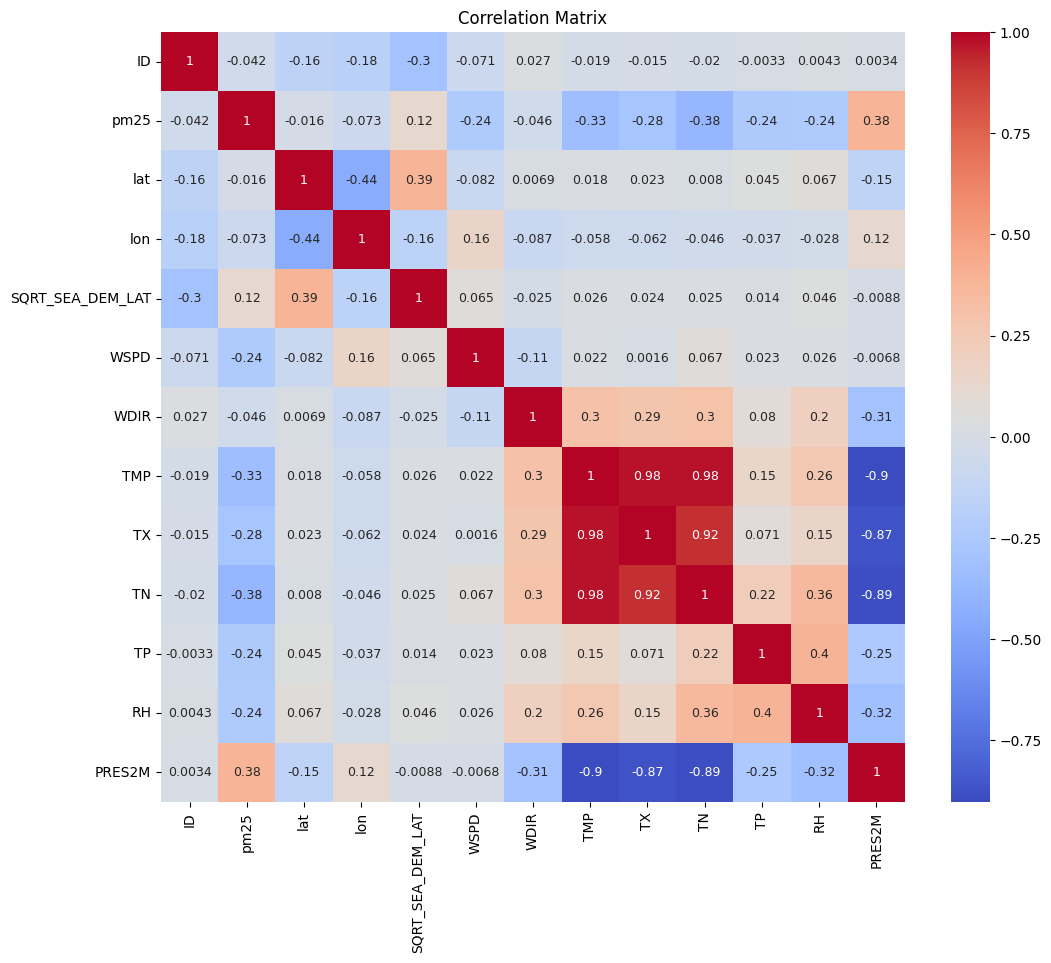

In [ ]:
data_exclude_time = df.drop('time', axis=1)
corr = data_exclude_time.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', annot_kws={'size': 9})
plt.title('Correlation Matrix')
plt.show()

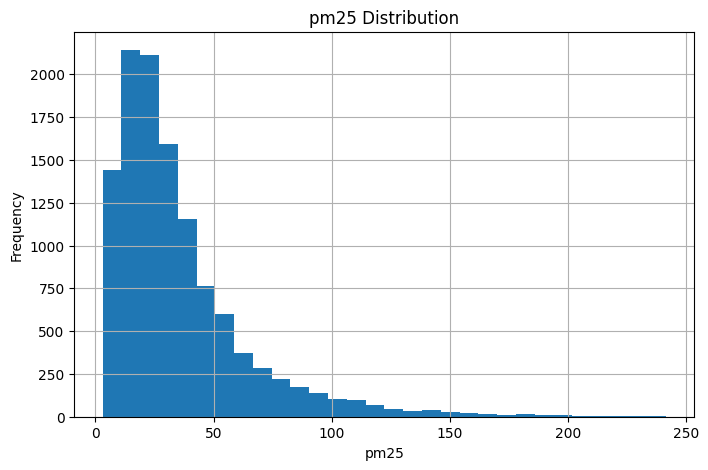

In [ ]:
df['pm25'].hist(bins=30, figsize=(8, 5))
plt.xlabel('pm25')
plt.ylabel('Frequency')
plt.title('pm25 Distribution')
plt.show()

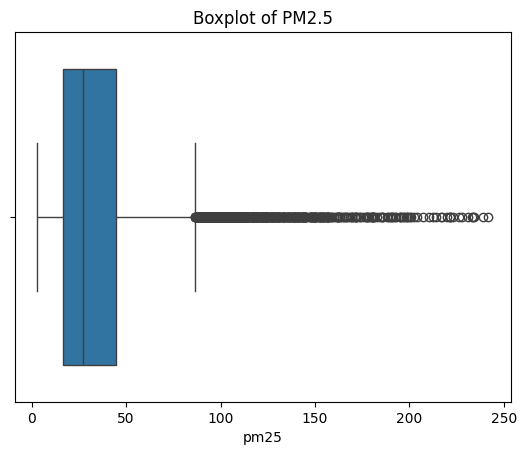

In [ ]:
sns.boxplot(x=df['pm25'])
plt.title('Boxplot of PM2.5')
plt.show()

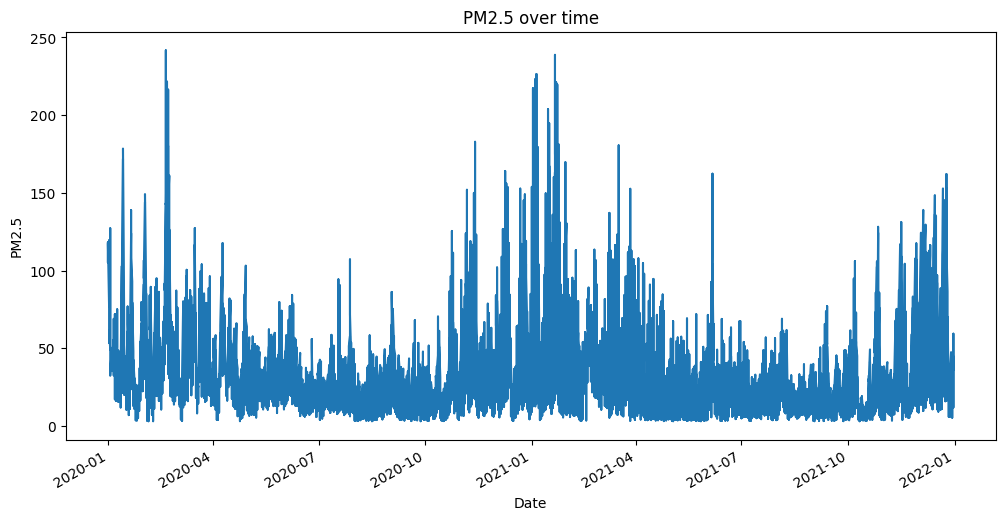

In [ ]:
df['time'] = pd.to_datetime(df['time'])
df.set_index('time')['pm25'].plot(figsize=(12,6))
plt.title('PM2.5 over time')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.show()

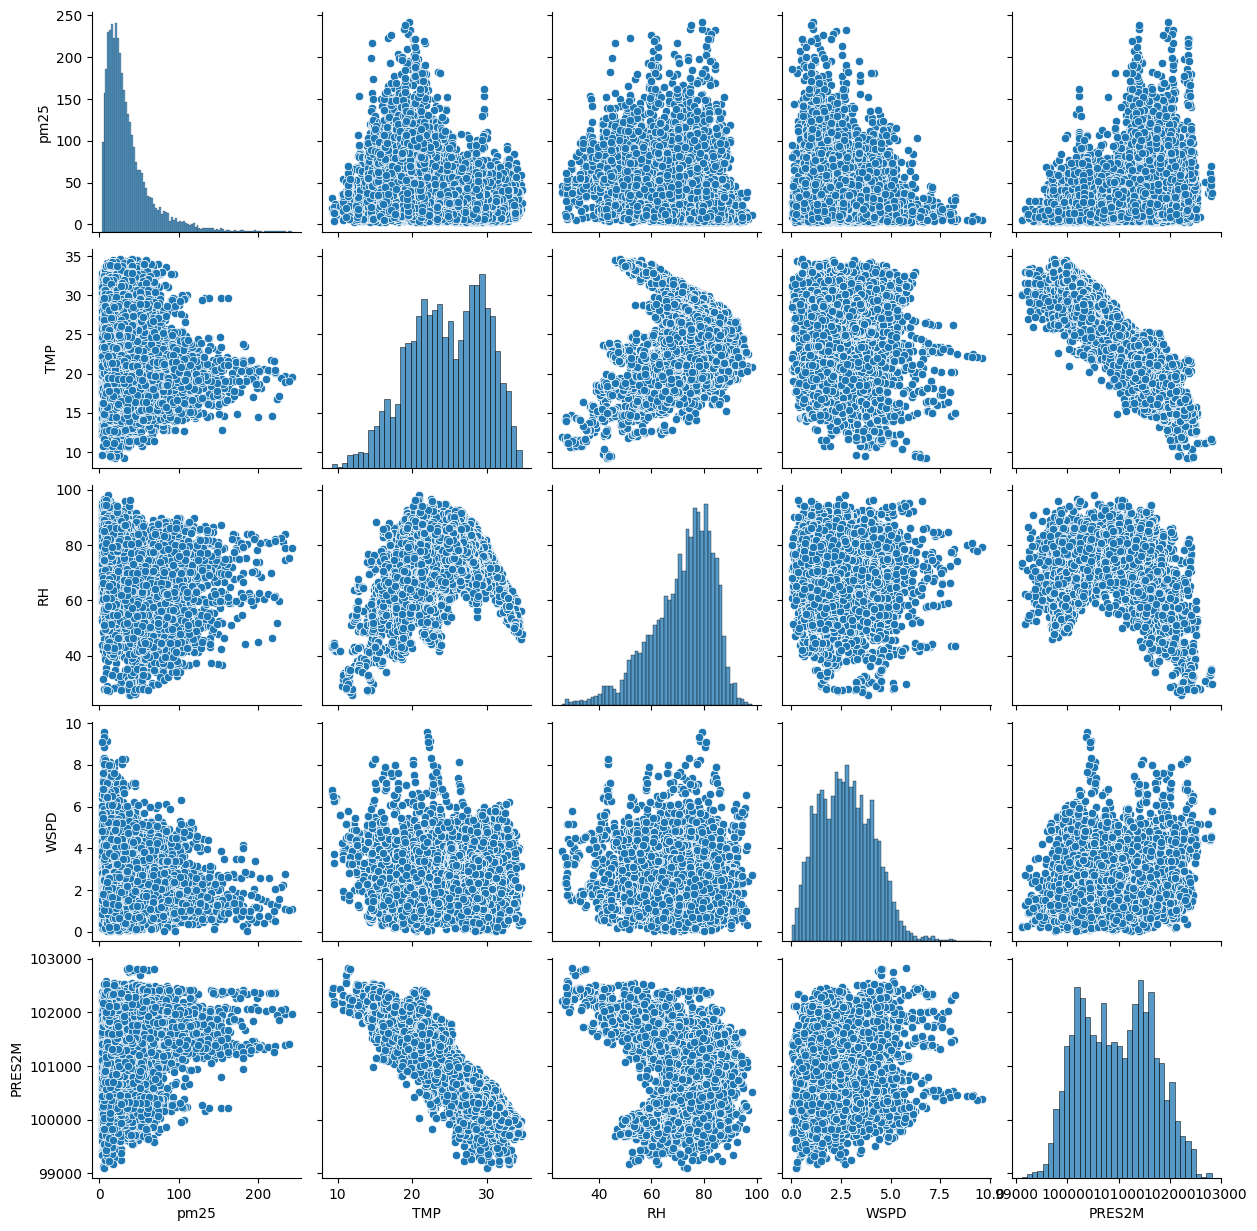

In [ ]:
sns.pairplot(df[['pm25', 'TMP', 'RH', 'WSPD', 'PRES2M']])
plt.show()

Dựa vào các biểu đồ trên, ta nhận thấy
- Ảnh hưởng của nhiệt độ, độ ẩm, tốc độ gió, áp suất khí quyển đến PM2.5:
  + Nhiệt độ trung bình (TMP): nhiệt độ có tương quan âm nhưng không mạnh, cho thấy khi nhiệt độ tăng thì nồng độ PM2.5 có xu hướng giảm nhẹ
  + Độ ẩm (RH): độ ẩm có tương quan dương nhẹ với PM2.5, cho thấy khi độ ẩm tăng thì PM2.5 có xu hướng giảm nhẹ
  + Tốc độ gió (WSPD): thể hiện tương quan âm vừa với PM2.5, cho thấy tốc độ gió càng lớn thì nồng độ PM2.5 có xu hướng giảm
  + Áp suất khí quyển (PRES2M): thể hiện tương quan dương vừa với PM2.5, cho thấy khi áp suất lớn thì nồng đọo PM2.5 có xu hướng lớn theo
- Biến khí tượng quan trọng nhất trong dự đoán PM2.5: tốc độ gió (WSPD) do nó thể hiện tương quan âm mạnh nhất đối với biến PM2.5
- Các điều kiện thời tiết đặc biệt ảnh hưởng đến nồng độ PM2.5
  + Nhiệp độ thấp + độ ẩm cao làm tăng nồng độ PM2.5 do khả năng khuếch tán kém và sự hấp thụ nước của bụi
  + Lặng gió làm giảm khả năng phân tán của bụi, làm tăng nồng độ PM2.5
  + Áp suất khí quyển cao làm ức chế sự khuếch tán của PM2.5 làm tăng nồng độ của chúng

Split sets

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
selected_features = ['SQRT_SEA_DEM_LAT', 'WSPD', 'WDIR', 'TMP', 'TX', 'TN', 'TP', 'RH', 'PRES2M']

In [ ]:
x = df[selected_features]
y = df['pm25']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
model_RF = RandomForestRegressor(random_state=42)
model_RF.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
pred_RF = model_RF.predict(x_test)
pred_RF

array([50.36299169, 73.14024953, 25.50526986, ..., 88.36398213,
       39.98891858, 29.8221788 ])

In [ ]:
RF_score = model_RF.score(x_test, y_test)
print("Random Forest Score:", RF_score)

Random Forest Score: 0.6748662976326336


In [ ]:
def get_metrics(y_test, y_pred):
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print('MSE:', mse)
  print('RMSE:', rmse)
  print('MAE:', mae)
  print('R2:', r2)

In [ ]:
get_metrics(y_test, pred_RF)

MSE: 273.17937611638746
RMSE: 16.52813891871639
MAE: 10.925603510299716
R2: 0.6748662976326336


XGBoost

In [ ]:
import xgboost as xg

In [ ]:
xgb_r = xg.XGBRegressor(objective='reg:linear', n_estimators=10, seed=123)
xgb_r.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:24:26] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=10, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

In [ ]:
pred_XGB = xgb_r.predict(x_test)
pred_XGB

array([ 58.83276 ,  81.05042 ,  22.811707, ..., 107.07032 ,  30.828289,
        33.077835], dtype=float32)

In [ ]:
get_metrics(y_test, pred_XGB)

MSE: 347.8487276989681
RMSE: 18.65070314221338
MAE: 12.654553346500979
R2: 0.5859960356144949


Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
model_GBR = GradientBoostingRegressor(random_state=42)
model_GBR.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [ ]:
pred_GBR = model_GBR.predict(x_test)
pred_GBR

array([64.41587326, 81.45987815, 24.98352717, ..., 77.24270495,
       29.61551601, 31.23403337])

In [ ]:
get_metrics(y_test, pred_GBR)

MSE: 381.588053285687
RMSE: 19.53427892924863
MAE: 13.137633547205938
R2: 0.5458400326272331


Support vector regression

In [ ]:
from sklearn.svm import SVR

In [ ]:
model_SVR = SVR()
model_SVR.fit(x_train, y_train)

SVR()

In [ ]:
pred_SVR = model_SVR.predict(x_test)
pred_SVR

array([27.44753015, 27.63107879, 27.21971713, ..., 27.4322021 ,
       26.97771793, 27.04281874])

In [ ]:
get_metrics(y_test, pred_SVR)

MSE: 902.1366483622417
RMSE: 30.035589695596816
MAE: 19.382683444990718
R2: -0.07370853793273335


Fully-connected neural networks

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
class PM25NN(nn.Module):
  def __init__(self, input_dim):
    super().__init__()
    self.fc = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.fc(x)

In [ ]:
model = PM25NN(x_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
epochs = 100
for epoch in range(epochs):
  model.train()
  optimizer.zero_grad()